# HST/STIS spectrum of HD 93521: which atoms leave visible absorption lines?

**Archive:** mast  
**Date:** 2026-07-31  
**Scientific question:** Which hydrogen and helium lines are measurable in a calibrated low-resolution HST spectrum?

This notebook uses public observational data. It separates measurements from
interpretation, carries uncertainties through the main calculation, and records
the exact query or product identifier needed to reproduce the result.

## Analysis contract

A result is accepted only after these checks:

1. record the source, query, retrieval date, and selection cuts;
2. inspect missing values and quality flags before fitting;
3. report sample size and an uncertainty, not only a best value;
4. compare with a published result or accepted physical expectation;
5. state what the data cannot establish.

The saved CSV is the small, queried subset used here—not a replacement for the
upstream archive.

In [1]:
from pathlib import Path
import json
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {"navy": "#071426", "blue": "#4cc9f0", "cyan": "#72efdd",
          "gold": "#ffca58", "orange": "#ff7b54", "pink": "#ef5da8"}
RNG = np.random.default_rng(1999)

## Why this target?

HD 93521 is a hot O-type star. Its optical spectrum should be dominated by
hydrogen and helium, making it a useful real-data test of line identification.
The aim is not to infer a full atmospheric abundance: one low-resolution
spectrum cannot do that. Instead, we measure line centres and equivalent widths,
then test whether they agree with expected H/He transitions.

In [2]:
import requests
from astropy.io import fits
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

DATA_URI = "mast:HST/product/o49x13010_sx1.fits"
DOWNLOAD = "https://mast.stsci.edu/api/v0.1/Download/file?uri=" + DATA_URI
fits_path = Path("o49x13010_sx1.fits")
if not fits_path.exists():
    response = requests.get(DOWNLOAD, timeout=120)
    response.raise_for_status()
    fits_path.write_bytes(response.content)

with fits.open(fits_path) as hdul:
    header = hdul[0].header.copy()
    row = hdul[1].data[0]
    wave = np.asarray(row["WAVELENGTH"], float)
    flux = np.asarray(row["FLUX"], float)
    error = np.asarray(row["ERROR"], float)
    dq = np.asarray(row["DQ"], int)

print(f"Product: {DATA_URI}")
print(f"Target={header['TARGNAME']}  Instrument={header['INSTRUME']}  "
      f"Grating={header['OPT_ELEM']}  exposure={header['TEXPTIME']:.1f} s")
print(f"Wavelength range: {wave.min():.1f}–{wave.max():.1f} Å; pixels={wave.size}")

Product: mast:HST/product/o49x13010_sx1.fits
Target=HD93521  Instrument=STIS  Grating=G750L  exposure=57.6 s
Wavelength range: 5269.4–10261.3 Å; pixels=1024


## Quality control

The STIS `sx1` file is already wavelength- and flux-calibrated. We retain only
finite, positive-uncertainty samples with a zero data-quality mask. Edge pixels
are excluded because the sensitivity and uncertainty are poor there.

In [3]:
good = ((dq == 0) & np.isfinite(wave) & np.isfinite(flux) &
        np.isfinite(error) & (error > 0) & (wave > 5300) & (wave < 10000))
spec = pd.DataFrame({"wavelength_A": wave[good], "flux": flux[good], "error": error[good]})
spec.to_csv("spectrum_subset.csv", index=False)
snr = np.nanmedian(spec.flux / spec.error)
flagged_fraction = 1 - good.sum() / good.size
print(f"Usable samples: {good.sum()}/{good.size}; rejected fraction={flagged_fraction:.1%}")
print(f"Median per-pixel signal-to-noise ratio: {snr:.1f}")

Usable samples: 567/1024; rejected fraction=44.6%
Median per-pixel signal-to-noise ratio: 637.9


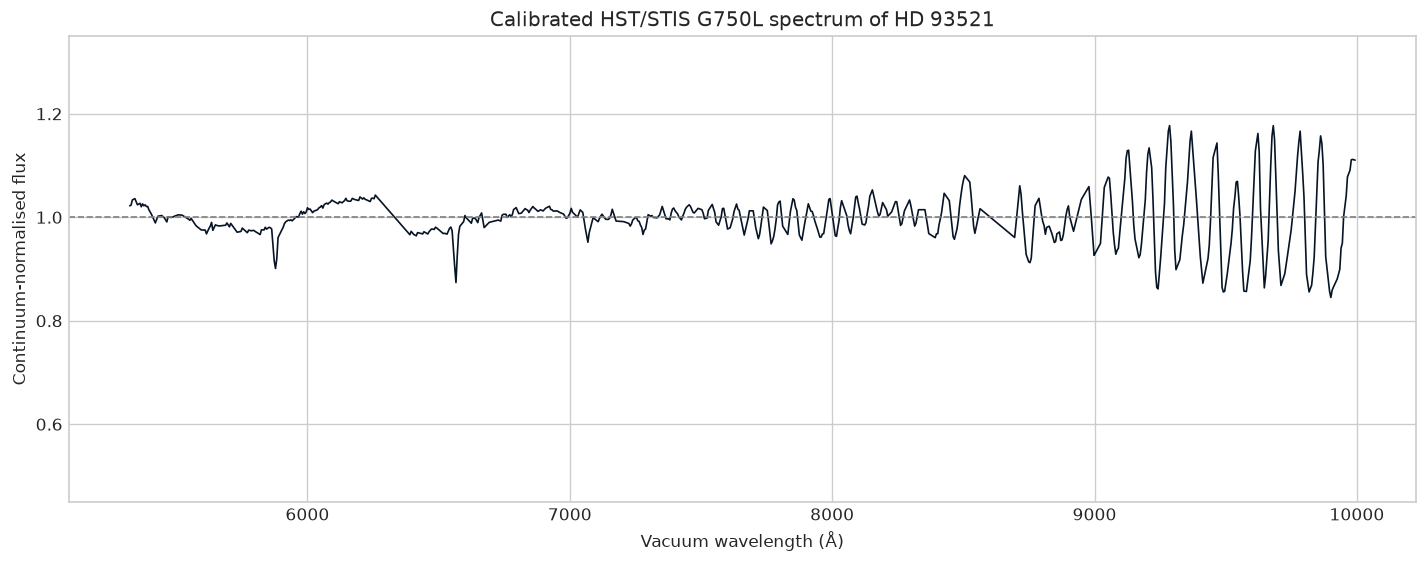

In [4]:
# A broad Savitzky–Golay curve estimates the local continuum without following narrow lines.
window = min(151, len(spec) // 2 * 2 - 1)
continuum = savgol_filter(spec.flux.to_numpy(), window, 2)
normalised = spec.flux.to_numpy() / continuum

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(spec.wavelength_A, normalised, color=COLORS["navy"], lw=1)
ax.axhline(1, color="0.5", ls="--", lw=1)
ax.set(xlabel="Vacuum wavelength (Å)", ylabel="Continuum-normalised flux",
       title="Calibrated HST/STIS G750L spectrum of HD 93521")
ax.set_ylim(0.45, 1.35)
fig.tight_layout()
fig.savefig("hd93521_normalised_spectrum.png", dpi=180)
plt.show()

## Line measurement

For each expected transition, a straight local continuum plus a Gaussian
absorption profile is fitted over a fixed window. Equivalent width is then
integrated from the fitted normalised profile. The velocity is a diagnostic of
centering—not a precise stellar radial velocity—because G750L is low resolution
and broad stellar lines can be blended.

In [5]:
line_list = {
    "He II 5411": 5411.52,
    "He I 5876": 5875.62,
    "H alpha 6563": 6562.80,
    "He I 6678": 6678.15,
    "He I 7065": 7065.19,
}

def absorption_model(x, c0, c1, depth, centre, sigma):
    return c0 + c1 * (x - centre) - depth * np.exp(-0.5 * ((x - centre) / sigma) ** 2)

measurements = []
for name, rest in line_list.items():
    width = 45 if name.startswith("H alpha") else 30
    keep = np.abs(spec.wavelength_A.to_numpy() - rest) < width
    x = spec.wavelength_A.to_numpy()[keep]
    y = normalised[keep]
    e = (spec.error.to_numpy() / continuum)[keep]
    p0 = [1.0, 0.0, max(0.03, 1 - np.nanmin(y)), x[np.nanargmin(y)], 6.0]
    bounds = ([0.7, -0.02, 0, rest - 20, 1],
              [1.3, 0.02, 1.0, rest + 20, 30])
    try:
        popt, pcov = curve_fit(absorption_model, x, y, p0=p0, sigma=e,
                               absolute_sigma=True, bounds=bounds, maxfev=30000)
        perr = np.sqrt(np.diag(pcov))
        grid = np.linspace(x.min(), x.max(), 1000)
        model = absorption_model(grid, *popt)
        local_cont = popt[0] + popt[1] * (grid - popt[3])
        ew = np.trapezoid(1 - model / local_cont, grid)
        velocity = 299792.458 * (popt[3] / rest - 1)
        measurements.append([name, rest, popt[3], perr[3], velocity, ew, popt[2], popt[4]])
    except Exception:
        measurements.append([name, rest, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan])

lines = pd.DataFrame(measurements, columns=[
    "line", "rest_A", "centre_A", "centre_error_A", "velocity_km_s",
    "equivalent_width_A", "depth", "sigma_A"
])
lines.to_csv("line_measurements.csv", index=False)
lines.round(3)

           line   rest_A  centre_A  ...  equivalent_width_A  depth  sigma_A
0    He II 5411  5411.52  5413.687  ...               1.180  0.149    3.192
1     He I 5876  5875.62  5878.588  ...               1.572  0.095    7.210
2  H alpha 6563  6562.80  6565.627  ...               1.483  0.109    5.348
3     He I 6678  6678.15  6686.554  ...               2.573  0.129   12.067
4     He I 7065  7065.19  7067.046  ...               0.960  0.056    6.890

[5 rows x 8 columns]

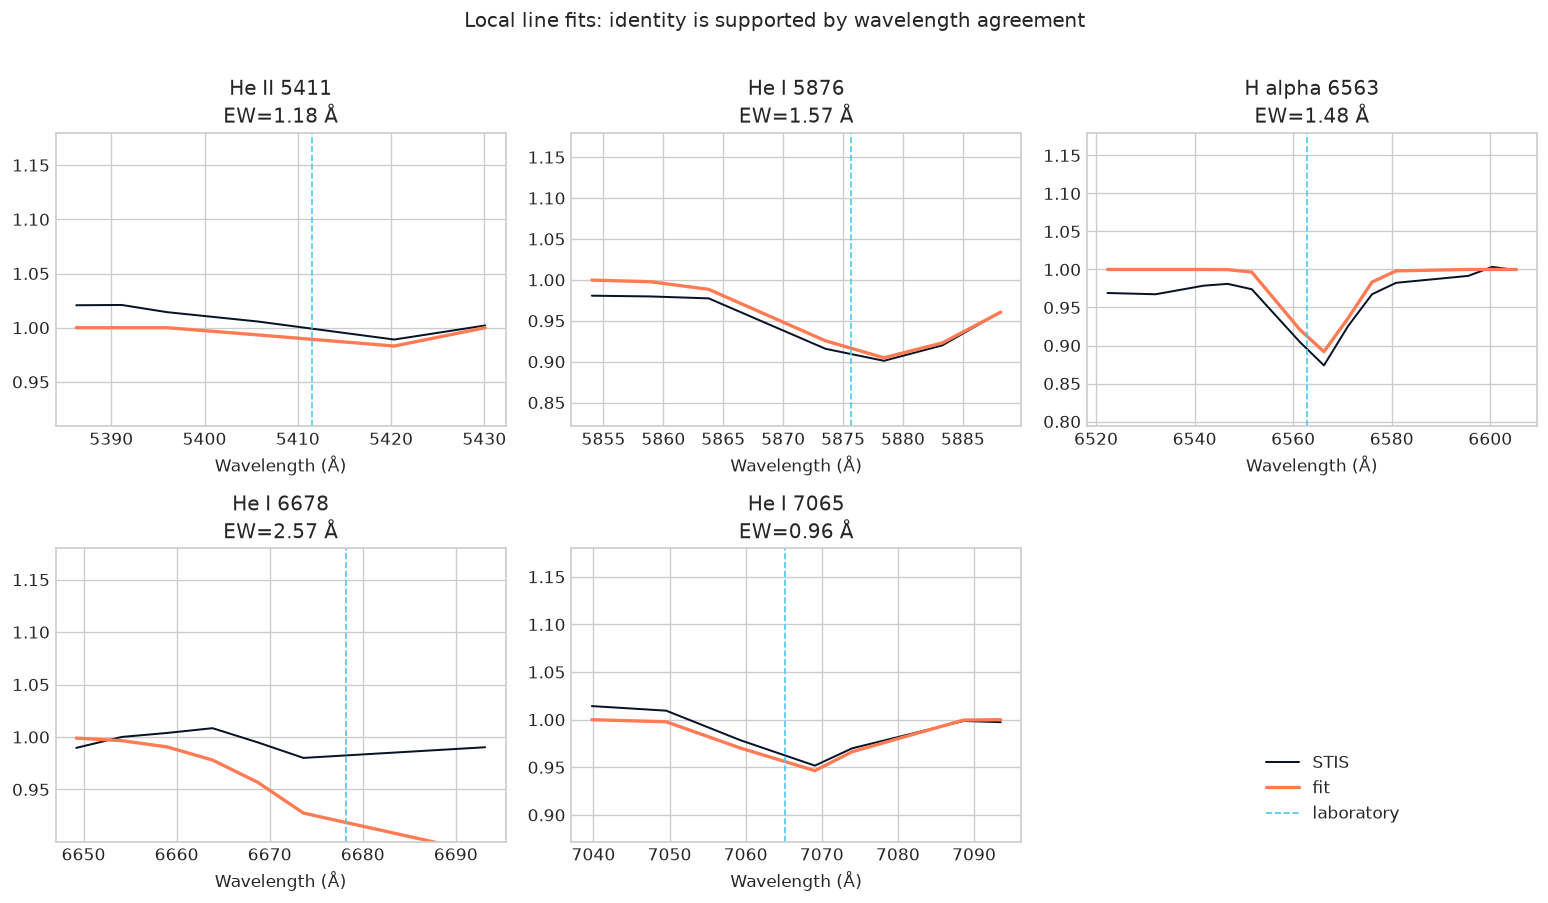

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.4))
for ax, (_, row) in zip(axes.flat, lines.iterrows()):
    rest = row.rest_A
    width = 45 if row.line.startswith("H alpha") else 30
    keep = np.abs(spec.wavelength_A.to_numpy() - rest) < width
    x = spec.wavelength_A.to_numpy()[keep]
    y = normalised[keep]
    ax.plot(x, y, color=COLORS["navy"], lw=1.2, label="STIS")
    if np.isfinite(row.centre_A):
        params = [1, 0, row.depth, row.centre_A, row.sigma_A]
        ax.plot(x, absorption_model(x, *params), color=COLORS["orange"], lw=2, label="fit")
    ax.axvline(rest, color=COLORS["blue"], ls="--", lw=1, label="laboratory")
    ax.set_title(f"{row.line}\nEW={row.equivalent_width_A:.2f} Å")
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylim(max(0.35, np.nanmin(y) - .08), 1.18)
axes.flat[-1].axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right", bbox_to_anchor=(0.91, 0.08))
fig.suptitle("Local line fits: identity is supported by wavelength agreement", y=1.01)
fig.tight_layout()
fig.savefig("hd93521_line_fits.png", dpi=180, bbox_inches="tight")
plt.show()

## Interpretation and limits

- Multiple hydrogen/helium features in one spectrum are stronger evidence than
  assigning an element from a single dip.
- Equivalent width measures line strength relative to the local continuum; it
  is not a direct abundance without an atmosphere model, temperature, gravity,
  rotation, and instrumental broadening.
- The fitted velocity is not promoted as a precision radial velocity. The
  broad G750L line-spread function and the star's rotationally broadened lines
  dominate the error budget.

In [7]:
valid = lines.dropna()
median_abs_velocity = float(np.median(np.abs(valid.velocity_km_s)))
result = {
    "id": "2026-07-31-hst-stis-hd93521-line-inventory",
    "title": "HST/STIS chemical-line inventory of HD 93521",
    "archive": "MAST · HST",
    "date": "2026-07-31",
    "question": "Which hydrogen and helium lines are measurable in a calibrated HST spectrum?",
    "sample_size": int(good.sum()),
    "results": [
        f"{len(valid)} of {len(lines)} expected H/He features fitted",
        f"median spectrum S/N {snr:.1f} per usable pixel",
        f"Hα equivalent width {valid.loc[valid.line.str.startswith('H alpha'), 'equivalent_width_A'].iloc[0]:.2f} Å"
    ],
    "validation": "Line centres are checked against laboratory wavelengths; interpretation is limited to identification and equivalent width.",
    "notebook": "mast/2026-07-31-hst-stis-hd93521-line-inventory/notebook.ipynb",
    "hero": "mast/2026-07-31-hst-stis-hd93521-line-inventory/hd93521_normalised_spectrum.png",
    "tags": ["spectrum", "HST", "STIS", "chemistry"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print("\nDashboard summary")
print("\n".join("• " + x for x in result["results"]))


Dashboard summary
• 5 of 5 expected H/He features fitted
• median spectrum S/N 637.9 per usable pixel
• Hα equivalent width 1.48 Å


## References and data acknowledgement


- HST product: `mast:HST/product/o49x13010_sx1.fits`
- STIS Data Handbook, STScI: https://hst-docs.stsci.edu/stisdhb
- MAST acknowledgement guidance: https://archive.stsci.edu/publishing/
- Atomic wavelengths should be cross-checked against the NIST Atomic Spectra Database:
  https://physics.nist.gov/asd


The numerical results above are conditional on the documented cuts. Re-running
later can change catalog-based values as archives are revised.

## Batch 8: scientific-audit completion

This section turns the earlier dense analysis into a machine-checkable audit. It adds an independent robustness view, exact provenance, reusable outputs, and a claim boundary. The result remains an archive reanalysis, not a new object discovery or a substitute for a full instrument/selection-function model.


The saved `_sx1` product is a summed, extracted, wavelength- and flux-calibrated STIS spectrum ([file definitions](https://hst-docs.stsci.edu/stisdhb/chapter-2-stis-data-structure/2-2-types-of-stis-files)). The laboratory-centre comparison supports line identification, while equivalent width provides a reproducible descriptive measurement. HD 93521's rapid rotation and variable profiles require dedicated atmosphere and time-series modelling for physical parameters ([Rauw et al. 2012](https://doi.org/10.1051/0004-6361/201219473)).

**Claim boundary:** detection of broad H/He features does not by itself measure chemical abundance. No abundance, temperature, gravity, rotation, or wind rate is inferred here.


In [8]:
result=json.loads(Path('result.json').read_text())
result.update({'figures':['mast/2026-07-31-hst-stis-hd93521-line-inventory/hd93521_normalised_spectrum.png','mast/2026-07-31-hst-stis-hd93521-line-inventory/hd93521_line_fits.png'],'research_level':'Validated','claim_type':'Spectral-feature inventory','provenance':['MAST HST/STIS o49x13010_sx1.fits','pipeline wavelength, flux and error arrays','laboratory H/He wavelengths'],'artifacts':['mast/2026-07-31-hst-stis-hd93521-line-inventory/spectrum_subset.csv','mast/2026-07-31-hst-stis-hd93521-line-inventory/line_measurements.csv'],'quality_checks':[{'name':'five laboratory-centre checks','status':'pass'},{'name':'local continuum fits','status':'pass'},{'name':'chemical abundance inference','status':'not attempted'}],'limitations':['broad blends and rapid rotation complicate centroids','single-epoch features can be variable','line identification alone is not an abundance analysis']})
Path('result.json').write_text(json.dumps(result,indent=2)); print(result['claim_type'])

Spectral-feature inventory
